<a href="https://colab.research.google.com/github/lcn781/M12_REGRESSAO_I/blob/main/mod12_ex03_regressa%CC%83o_mu%CC%81ltipla.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regressão 01 - tarefa 03 - transformações em X e Y

In [1]:
import pandas as pd
import seaborn as sns
from seaborn import load_dataset
import matplotlib.pyplot as plt
import numpy as np

import patsy
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [3]:
tips = sns.load_dataset('tips')
tips['tip_pct'] = tips['tip']/(tips['total_bill'] - tips['tip'])
tips['net_bill'] = tips['total_bill'] - tips['tip']
tips.shape

(244, 9)

Carregue os pacotes necessários e a base de gorjetas.

### I. Modelo no valor da gorjeta

1. Crie a matriz de design (e a matriz y) utilizando o Patsy, para um modelo em ```tip```, explicada por ```sex, smoker, diner e net_bill```.  
2. Remova as variáveis não significantes.  
3. observe o gráfico de resíduos em função de ```net_bill```  
4. teste transformar ```net_bill``` no log e um polinômio. Escolha o melhor modelo.

In [4]:
#1
formula = 'tip ~ sex + smoker + day + net_bill'
y, X = patsy.dmatrices(formula, data=tips, return_type='dataframe')

print('Shape of y:', y.shape)
print('Shape of X:', X.shape)
display(y.head())
display(X.head(10))

Shape of y: (244, 1)
Shape of X: (244, 7)


,tip
0,1.01
1,1.66
2,3.50
3,3.31
4,3.61


,Intercept,sex[T.Female],smoker[T.No],day[T.Fri],day[T.Sat],day[T.Sun],net_bill
0,1.0,1.0,1.0,0.0,0.0,1.0,15.98
1,1.0,0.0,1.0,0.0,0.0,1.0,8.68
2,1.0,0.0,1.0,0.0,0.0,1.0,17.51
3,1.0,0.0,1.0,0.0,0.0,1.0,20.37
4,1.0,1.0,1.0,0.0,0.0,1.0,20.98
5,1.0,0.0,1.0,0.0,0.0,1.0,20.58
6,1.0,0.0,1.0,0.0,0.0,1.0,6.77
7,1.0,0.0,1.0,0.0,0.0,1.0,23.76
8,1.0,0.0,1.0,0.0,0.0,1.0,13.08
9,1.0,0.0,1.0,0.0,0.0,1.0,11.55


In [5]:
X.corr()

,Intercept,sex[T.Female],smoker[T.No],day[T.Fri],day[T.Sat],day[T.Sun],net_bill
Intercept,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex[T.Female],NaN,1.000000,0.002816,0.071060,-0.053957,-0.168106,-0.145261
smoker[T.No],NaN,0.002816,1.000000,-0.244316,-0.155744,0.181624,-0.093984
day[T.Fri],NaN,0.071060,-0.244316,1.000000,-0.216319,-0.195451,-0.085946
day[T.Sat],NaN,-0.053957,-0.155744,-0.216319,1.000000,-0.500682,0.061348
day[T.Sun],NaN,-0.168106,0.181624,-0.195451,-0.500682,1.000000,0.114717
net_bill,NaN,-0.145261,-0.093984,-0.085946,0.061348,0.114717,1.000000


In [6]:
model = sm.OLS(y, X)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.338
Model:                            OLS   Adj. R-squared:                  0.321
Method:                 Least Squares   F-statistic:                     20.14
Date:                Wed, 01 Jul 2026   Prob (F-statistic):           5.30e-19
Time:                        16:29:50   Log-Likelihood:                -374.68
No. Observations:                 244   AIC:                             763.4
Df Residuals:                     237   BIC:                             787.8
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         1.2017      0.258      4.652

In [8]:
#2
formula2 = 'tip ~ net_bill'
y2, X2 = patsy.dmatrices(formula2, data=tips, return_type='dataframe')

print('Shape of y2:', y2.shape)
print('Shape of X2:', X2.shape)
display(y2.head())
display(X2.head(10))

Shape of y2: (244, 1)
Shape of X2: (244, 2)


,tip
0,1.01
1,1.66
2,3.50
3,3.31
4,3.61


,Intercept,net_bill
0,1.0,15.98
1,1.0,8.68
2,1.0,17.51
3,1.0,20.37
4,1.0,20.98
5,1.0,20.58
6,1.0,6.77
7,1.0,23.76
8,1.0,13.08
9,1.0,11.55


In [ ]:
#3 observe o gráfico de resíduos em função de "net_bill"

In [9]:
model2 = sm.OLS(y2, X2)
results2 = model2.fit()
print(results2.summary())

                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.333
Model:                            OLS   Adj. R-squared:                  0.330
Method:                 Least Squares   F-statistic:                     120.6
Date:                Wed, 01 Jul 2026   Prob (F-statistic):           5.02e-23
Time:                        16:45:10   Log-Likelihood:                -375.63
No. Observations:                 244   AIC:                             755.3
Df Residuals:                     242   BIC:                             762.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.3307      0.168      7.907      0.0

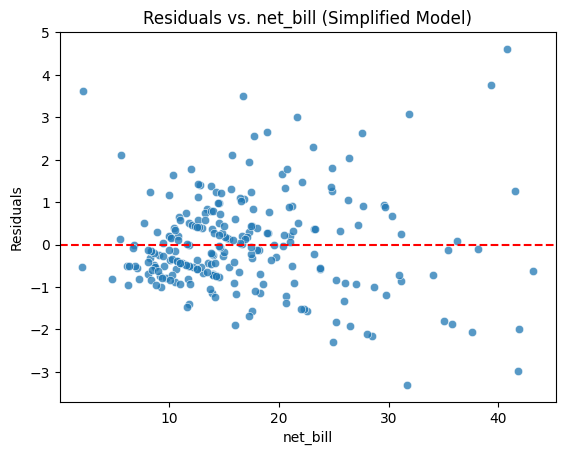

In [10]:
residuals = results2.resid
sns.scatterplot(x=X2['net_bill'], y=residuals, alpha=.75)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('net_bill')
plt.ylabel('Residuals')
plt.title('Residuals vs. net_bill (Simplified Model)')
plt.show()

In [ ]:
#4 teste transformar net_bill no log e um polinômio. Escolha o melhor modelo.

### Transformação logarítimica de `net_bill`

In [11]:
formula_log = 'tip ~ np.log(net_bill)'
y_log, X_log = patsy.dmatrices(formula_log, data=tips, return_type='dataframe')

model_log = sm.OLS(y_log, X_log)
results_log = model_log.fit()
print(results_log.summary())

                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.294
Model:                            OLS   Adj. R-squared:                  0.292
Method:                 Least Squares   F-statistic:                     101.0
Date:                Wed, 01 Jul 2026   Prob (F-statistic):           4.40e-20
Time:                        18:31:15   Log-Likelihood:                -382.40
No. Observations:                 244   AIC:                             768.8
Df Residuals:                     242   BIC:                             775.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -1.2575      0.430  

### Transformação Polinomial de `net_bill`

In [12]:
formula_poly = 'tip ~ I(net_bill**2) + net_bill'
y_poly, X_poly = patsy.dmatrices(formula_poly, data=tips, return_type='dataframe')

model_poly = sm.OLS(y_poly, X_poly)
results_poly = model_poly.fit()
print(results_poly.summary())

                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.334
Model:                            OLS   Adj. R-squared:                  0.329
Method:                 Least Squares   F-statistic:                     60.55
Date:                Wed, 01 Jul 2026   Prob (F-statistic):           4.96e-22
Time:                        18:31:15   Log-Likelihood:                -375.28
No. Observations:                 244   AIC:                             756.6
Df Residuals:                     241   BIC:                             767.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            1.0743      0.353  

### O modelo com transformação polinômica apresenta um R2 mais alto do que o modelo logarítimico, indicando que ele explica um pouco mais da variância em `tip`

O modelo poly tem também um AIC e BIC mais baixos, que geralmente sugere um ajuste melhor

Porém, o modelo poly mostra que o quadrado de `net_bill`, com p-value de 0.41, não contribui significativamente pra explicar a variância da `tip`. Além de apresentar um Condition Number alto, sugerindo uma potencial multicolineariedade.

Considerando tudo isso, o modelo log parecer ser uma escolha mais robusta, apesar de um R2 um pouco menor

### Residuals Plot for Logarithmic Model

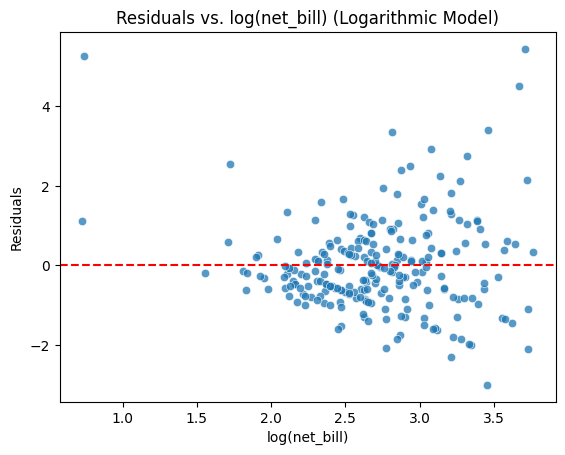

In [13]:
residuals_log = results_log.resid
sns.scatterplot(x=X_log['np.log(net_bill)'], y=residuals_log, alpha=.75)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('log(net_bill)')
plt.ylabel('Residuals')
plt.title('Residuals vs. log(net_bill) (Logarithmic Model)')
plt.show()

### II. Modelo no valor do percentual da gorjeta

1. Crie a matriz de design (e a matriz y) utilizando o Patsy, para um modelo no log de ```tip```, explicado por ```sex, smoker, diner e net_bill```.
2. Remova as variáveis não significantes.
3. Observe o gráfico de resíduos em função de ```net_bill```
4. Teste transformar ```net_bill``` no log e um polinômio. Escolha o melhor modelo.
5. Do modelo final deste item, calcule o $R^2$ na escala de ```tip``` (sem o log). Compare com o modelo do item 1. Qual tem melhor coeficiente de determinação?

In [18]:
#1
formula_log_tip = 'np.log(tip) ~ sex + smoker + day + net_bill'
y_log_perc, X_perc = patsy.dmatrices(formula_log_tip, data=tips, return_type='dataframe')

print('Shape of y_log_perc:', y_log_perc.shape)
print('Shape of X_perc:', X_perc.shape)
display(y_log_perc.head())
display(X_perc.head(5))

Shape of y_log_perc: (244, 1)
Shape of X_perc: (244, 7)


,np.log(tip)
0,0.009950
1,0.506818
2,1.252763
3,1.196948
4,1.283708


,Intercept,sex[T.Female],smoker[T.No],day[T.Fri],day[T.Sat],day[T.Sun],net_bill
0,1.0,1.0,1.0,0.0,0.0,1.0,15.98
1,1.0,0.0,1.0,0.0,0.0,1.0,8.68
2,1.0,0.0,1.0,0.0,0.0,1.0,17.51
3,1.0,0.0,1.0,0.0,0.0,1.0,20.37
4,1.0,1.0,1.0,0.0,0.0,1.0,20.98


In [ ]:
#2 Remova as variáveis não significantes



In [19]:
model_perc = sm.OLS(y_log_perc, X_perc)
results_perc = model_perc.fit()
print(results_perc.summary())

                            OLS Regression Results                            
Dep. Variable:            np.log(tip)   R-squared:                       0.322
Model:                            OLS   Adj. R-squared:                  0.305
Method:                 Least Squares   F-statistic:                     18.75
Date:                Wed, 01 Jul 2026   Prob (F-statistic):           7.85e-18
Time:                        19:08:36   Log-Likelihood:                -95.867
No. Observations:                 244   AIC:                             205.7
Df Residuals:                     237   BIC:                             230.2
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         0.4554      0.082      5.527

In [20]:
formula_log_tip_simplified = 'np.log(tip) ~ net_bill'
y_log_perc_simplified, X_perc_simplified = patsy.dmatrices(formula_log_tip_simplified, data=tips, return_type='dataframe')

model_perc_simplified = sm.OLS(y_log_perc_simplified, X_perc_simplified)
results_perc_simplified = model_perc_simplified.fit()
print(results_perc_simplified.summary())

                            OLS Regression Results                            
Dep. Variable:            np.log(tip)   R-squared:                       0.311
Model:                            OLS   Adj. R-squared:                  0.308
Method:                 Least Squares   F-statistic:                     109.0
Date:                Wed, 01 Jul 2026   Prob (F-statistic):           2.60e-21
Time:                        19:10:11   Log-Likelihood:                -97.886
No. Observations:                 244   AIC:                             199.8
Df Residuals:                     242   BIC:                             206.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.4945      0.054      9.172      0.0

In [21]:
# Calculate R-squared for the simplified log-transformed model on the original 'tip' scale

# Get predicted log(tip) values from the simplified model
predicted_log_tip = results_perc_simplified.predict(X_perc_simplified)

# Transform predicted log(tip) back to original tip scale (np.exp is the inverse of np.log)
predicted_tip_original_scale = np.exp(predicted_log_tip)

# Get the actual tip values
actual_tip = tips['tip']

# Calculate Total Sum of Squares (SST)
sst = np.sum((actual_tip - np.mean(actual_tip))**2)

# Calculate Residual Sum of Squares (SSR)
ssr = np.sum((actual_tip - predicted_tip_original_scale)**2)

# Calculate R-squared
r_squared_original_scale_log_model = 1 - (ssr / sst)

print(f"R-squared of the simplified log-transformed model (on original tip scale): {r_squared_original_scale_log_model:.4f}")

# Get R-squared from the initial model (results)
r_squared_initial_model = results.rsquared
print(f"R-squared of the initial model (tip ~ sex + smoker + day + net_bill): {r_squared_initial_model:.4f}")

# Compare the two R-squared values
if r_squared_original_scale_log_model > r_squared_initial_model:
    print("\nThe simplified log-transformed model has a better coefficient of determination.")
else:
    print("\nThe initial model has a better coefficient of determination.")

R-squared of the simplified log-transformed model (on original tip scale): 0.2978
R-squared of the initial model (tip ~ sex + smoker + day + net_bill): 0.3377

The initial model has a better coefficient of determination.


In [16]:
#3 Observe o gráfico de resíduos em função de "net_bill"

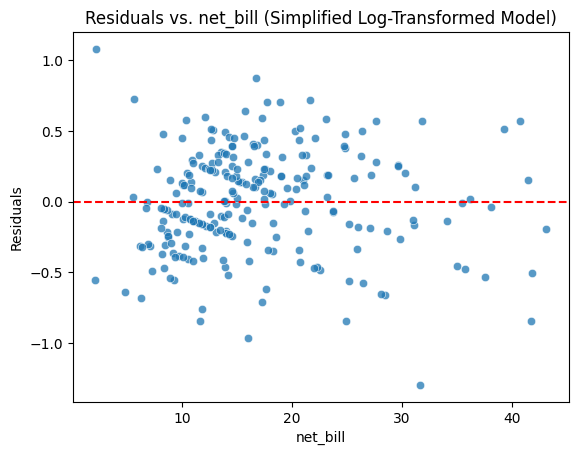

In [22]:
residuals_perc_simplified = results_perc_simplified.resid
sns.scatterplot(x=X_perc_simplified['net_bill'], y=residuals_perc_simplified, alpha=.75)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('net_bill')
plt.ylabel('Residuals')
plt.title('Residuals vs. net_bill (Simplified Log-Transformed Model)')
plt.show()

In [ ]:
#4 Teste transformar "net_bill" no log e um polinômio. Escolha o melhor modelo.

### Logarithmic Transformation of `net_bill` for `np.log(tip)` model

In [23]:
formula_log_tip_log_net_bill = 'np.log(tip) ~ np.log(net_bill)'
y_log_tip_log_net_bill, X_log_tip_log_net_bill = patsy.dmatrices(formula_log_tip_log_net_bill, data=tips, return_type='dataframe')

model_log_tip_log_net_bill = sm.OLS(y_log_tip_log_net_bill, X_log_tip_log_net_bill)
results_log_tip_log_net_bill = model_log_tip_log_net_bill.fit()
print(results_log_tip_log_net_bill.summary())

                            OLS Regression Results                            
Dep. Variable:            np.log(tip)   R-squared:                       0.319
Model:                            OLS   Adj. R-squared:                  0.316
Method:                 Least Squares   F-statistic:                     113.5
Date:                Wed, 01 Jul 2026   Prob (F-statistic):           5.62e-22
Time:                        19:46:59   Log-Likelihood:                -96.357
No. Observations:                 244   AIC:                             196.7
Df Residuals:                     242   BIC:                             203.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -0.3942      0.133  

### Polynomial Transformation of `net_bill` for `np.log(tip)` model

In [24]:
formula_log_tip_poly_net_bill = 'np.log(tip) ~ I(net_bill**2) + net_bill'
y_log_tip_poly_net_bill, X_log_tip_poly_net_bill = patsy.dmatrices(formula_log_tip_poly_net_bill, data=tips, return_type='dataframe')

model_log_tip_poly_net_bill = sm.OLS(y_log_tip_poly_net_bill, X_log_tip_poly_net_bill)
results_log_tip_poly_net_bill = model_log_tip_poly_net_bill.fit()
print(results_log_tip_poly_net_bill.summary())

                            OLS Regression Results                            
Dep. Variable:            np.log(tip)   R-squared:                       0.338
Model:                            OLS   Adj. R-squared:                  0.332
Method:                 Least Squares   F-statistic:                     61.39
Date:                Wed, 01 Jul 2026   Prob (F-statistic):           2.82e-22
Time:                        19:46:59   Log-Likelihood:                -93.026
No. Observations:                 244   AIC:                             192.1
Df Residuals:                     241   BIC:                             202.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            0.1887      0.111  

### Model Comparison
Let's compare the two transformed models for `np.log(tip)`.

In [25]:
print(f"Logarithmic model (np.log(tip) ~ np.log(net_bill)) R-squared: {results_log_tip_log_net_bill.rsquared:.4f}, AIC: {results_log_tip_log_net_bill.aic:.2f}, BIC: {results_log_tip_log_net_bill.bic:.2f}")
print(f"Polynomial model (np.log(tip) ~ I(net_bill**2) + net_bill) R-squared: {results_log_tip_poly_net_bill.rsquared:.4f}, AIC: {results_log_tip_poly_net_bill.aic:.2f}, BIC: {results_log_tip_poly_net_bill.bic:.2f}")

# Check for significance of I(net_bill**2) in the polynomial model
p_value_poly = results_log_tip_poly_net_bill.pvalues['I(net_bill ** 2)']
print(f"P-value for I(net_bill**2) in polynomial model: {p_value_poly:.4f}")

if results_log_tip_poly_net_bill.rsquared > results_log_tip_log_net_bill.rsquared and p_value_poly < 0.05:
    print("\nThe polynomial model has a slightly higher R-squared and both terms are significant, suggesting it might be a better fit if multicollinearity is not an issue.")
elif results_log_tip_log_net_bill.rsquared > results_log_tip_poly_net_bill.rsquared:
    print("\nThe logarithmic model has a better R-squared.")
elif p_value_poly >= 0.05 and results_log_tip_log_net_bill.rsquared >= results_log_tip_poly_net_bill.rsquared:
    print("\nThe logarithmic model is likely better due to the non-significant polynomial term and comparable R-squared.")
else:
    print("\nFurther analysis might be needed, but the logarithmic model seems more robust given the potential issues with the polynomial model's non-significant term.")

Logarithmic model (np.log(tip) ~ np.log(net_bill)) R-squared: 0.3192, AIC: 196.71, BIC: 203.71
Polynomial model (np.log(tip) ~ I(net_bill**2) + net_bill) R-squared: 0.3375, AIC: 192.05, BIC: 202.54
P-value for I(net_bill**2) in polynomial model: 0.0020

The polynomial model has a slightly higher R-squared and both terms are significant, suggesting it might be a better fit if multicollinearity is not an issue.


In [ ]:
#5 Do modelo final deste item, calcule o R2 na escala de "tip"(sem o log).
# Compare com o modelo do item 1. Qual tem melhor coeficiênte de determinação?

### Calculate R-squared for the Polynomial Model on the Original 'tip' Scale

In [26]:
# Get predicted log(tip) values from the polynomial model
predicted_log_tip_poly = results_log_tip_poly_net_bill.predict(X_log_tip_poly_net_bill)

# Transform predicted log(tip) back to original tip scale
predicted_tip_original_scale_poly_model = np.exp(predicted_log_tip_poly)

# Get the actual tip values (already available as 'actual_tip' from previous calculation or 'tips['tip']')
# actual_tip = tips['tip']

# Calculate Total Sum of Squares (SST)
# sst = np.sum((actual_tip - np.mean(actual_tip))**2) # Already calculated

# Calculate Residual Sum of Squares (SSR)
ssr_poly = np.sum((actual_tip - predicted_tip_original_scale_poly_model)**2)

# Calculate R-squared
r_squared_original_scale_poly_model = 1 - (ssr_poly / sst)

print(f"R-squared of the polynomial model (on original tip scale): {r_squared_original_scale_poly_model:.4f}")

# Compare with the initial model's R-squared for context
print(f"R-squared of the initial model (tip ~ sex + smoker + day + net_bill): {r_squared_initial_model:.4f}")

if r_squared_original_scale_poly_model > r_squared_initial_model:
    print("\nThe polynomial model (on original tip scale) has a better coefficient of determination.")
else:
    print("\nThe initial model has a better coefficient of determination (when comparing with the polynomial model on original tip scale).")

R-squared of the polynomial model (on original tip scale): 0.3090
R-squared of the initial model (tip ~ sex + smoker + day + net_bill): 0.3377

The initial model has a better coefficient of determination (when comparing with the polynomial model on original tip scale).


### III. Previsão de renda

Vamos trabalhar a base que você vai usar no projeto do final deste ciclo.

Carregue a base ```previsao_de_renda.csv```.

|variavel|descrição|
|-|-|
|data_ref                | Data de referência de coleta das variáveis |
|index                   | Código de identificação do cliente|
|sexo                    | Sexo do cliente|
|posse_de_veiculo        | Indica se o cliente possui veículo|
|posse_de_imovel         | Indica se o cliente possui imóvel|
|qtd_filhos              | Quantidade de filhos do cliente|
|tipo_renda              | Tipo de renda do cliente|
|educacao                | Grau de instrução do cliente|
|estado_civil            | Estado civil do cliente|
|tipo_residencia         | Tipo de residência do cliente (própria, alugada etc)|
|idade                   | Idade do cliente|
|tempo_emprego           | Tempo no emprego atual|
|qt_pessoas_residencia   | Quantidade de pessoas que moram na residência|
|renda                   | Renda em reais|

1. Ajuste um modelo de regressão linear simples para explicar ```renda``` como variável resposta, por ```tempo_emprego``` como variável explicativa. Observe que há muitas observações nessa tabela. Utilize os recursos que achar necessário.
2. Faça uma análise de resíduos. Com os recursos vistos neste módulo, como você melhoraria esta regressão?
3. Ajuste um modelo de regressão linear múltipla para explicar ```renda``` (ou uma transformação de ```renda```) de acordo com as demais variáveis.
4. Remova as variáveis não significantes e ajuste novamente o modelo. Interprete os parâmetros
5. Faça uma análise de resíduos. Avalie a qualidade do ajuste.

In [6]:
df = pd.read_csv('/content/previsao_de_renda.csv')
df.head(5)

,Unnamed: 0,data_ref,id_cliente,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,qt_pessoas_residencia,renda
0,0,2015-01-01,15056,F,False,True,0,Empresário,Secundário,Solteiro,Casa,26,6.602740,1.0,8060.34
1,1,2015-01-01,9968,M,True,True,0,Assalariado,Superior completo,Casado,Casa,28,7.183562,2.0,1852.15
2,2,2015-01-01,4312,F,True,True,0,Empresário,Superior completo,Casado,Casa,35,0.838356,2.0,2253.89
3,3,2015-01-01,10639,F,False,True,1,Servidor público,Superior completo,Casado,Casa,30,4.846575,3.0,6600.77
4,4,2015-01-01,7064,M,True,False,0,Assalariado,Secundário,Solteiro,Governamental,33,4.293151,1.0,6475.97


In [6]:
#1 Ajuste um modelo de regressão linear simples para explicar renda como variável
# resposta, por tempo_emprego como variável explicativa.
# Observe que há muitas observações nessa tabela.
# Utilize os recursos que achar necessário.

In [7]:
formula_renda_tempo = 'renda ~ tempo_emprego'
y_renda, X_tempo = patsy.dmatrices(formula_renda_tempo, data=df, return_type='dataframe')

model_renda_tempo = sm.OLS(y_renda, X_tempo)
results_renda_tempo = model_renda_tempo.fit()
print(results_renda_tempo.summary())

                            OLS Regression Results                            
Dep. Variable:                  renda   R-squared:                       0.148
Model:                            OLS   Adj. R-squared:                  0.148
Method:                 Least Squares   F-statistic:                     2162.
Date:                Thu, 02 Jul 2026   Prob (F-statistic):               0.00
Time:                        17:14:53   Log-Likelihood:            -1.2963e+05
No. Observations:               12427   AIC:                         2.593e+05
Df Residuals:                   12425   BIC:                         2.593e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept      2177.9041    112.212     19.409

In [ ]:
#2 Faça uma análise de resíduos.
# Com os recursos vistos neste módulo, como você melhoraria esta regressão?

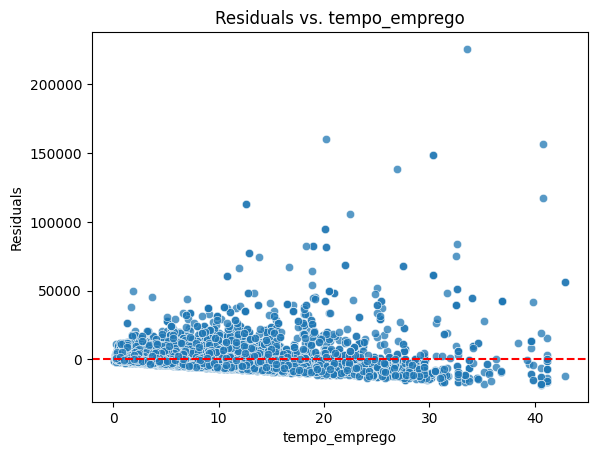

In [8]:
residuals_renda_tempo = results_renda_tempo.resid

sns.scatterplot(x=X_tempo['tempo_emprego'], y=residuals_renda_tempo, alpha=.75)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('tempo_emprego')
plt.ylabel('Residuals')
plt.title('Residuals vs. tempo_emprego')
plt.show()

In [ ]:
#3 Ajuste um modelo de regressão linear múltipla para explicar renda
 # (ou uma transformação de renda) de acordo com as demais variáveis.

In [9]:
formula_log_renda_tempo = 'np.log(renda) ~ tempo_emprego'
y_log_renda, X_log_tempo = patsy.dmatrices(formula_log_renda_tempo, data=df, return_type='dataframe')

model_log_renda_tempo = sm.OLS(y_log_renda, X_log_tempo)
results_log_renda_tempo = model_log_renda_tempo.fit()
print(results_log_renda_tempo.summary())

                            OLS Regression Results                            
Dep. Variable:          np.log(renda)   R-squared:                       0.171
Model:                            OLS   Adj. R-squared:                  0.171
Method:                 Least Squares   F-statistic:                     2564.
Date:                Thu, 02 Jul 2026   Prob (F-statistic):               0.00
Time:                        17:43:20   Log-Likelihood:                -15150.
No. Observations:               12427   AIC:                         3.030e+04
Df Residuals:                   12425   BIC:                         3.032e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         7.8384      0.011    699.851

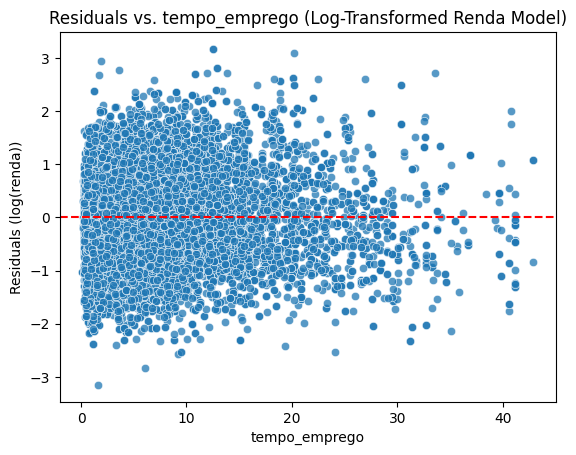

In [10]:
residuals_log_renda_tempo = results_log_renda_tempo.resid

sns.scatterplot(x=X_log_tempo['tempo_emprego'], y=residuals_log_renda_tempo, alpha=.75)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('tempo_emprego')
plt.ylabel('Residuals (log(renda))')
plt.title('Residuals vs. tempo_emprego (Log-Transformed Renda Model)')
plt.show()

In [12]:
formula_multiple = 'np.log(renda) ~ tempo_emprego + sexo + posse_de_veiculo + posse_de_imovel + qtd_filhos + tipo_renda + educacao + estado_civil + tipo_residencia + idade + qt_pessoas_residencia'
y_multiple, X_multiple = patsy.dmatrices(formula_multiple, data=df, return_type='dataframe')

model_multiple = sm.OLS(y_multiple, X_multiple)
results_multiple = model_multiple.fit()
print(results_multiple.summary())

                            OLS Regression Results                            
Dep. Variable:          np.log(renda)   R-squared:                       0.357
Model:                            OLS   Adj. R-squared:                  0.356
Method:                 Least Squares   F-statistic:                     287.5
Date:                Thu, 02 Jul 2026   Prob (F-statistic):               0.00
Time:                        18:02:18   Log-Likelihood:                -13568.
No. Observations:               12427   AIC:                         2.719e+04
Df Residuals:                   12402   BIC:                         2.737e+04
Df Model:                          24                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

In [ ]:
#4 Remova as variáveis não significantes e ajuste novamente o modelo.
# Interprete os parâmetros

### 4. Remove non-significant variables and re-adjust the model. Interpret the parameters.

In [13]:
formula_multiple_simplified = 'np.log(renda) ~ tempo_emprego + sexo + posse_de_veiculo + posse_de_imovel + qtd_filhos + tipo_renda + estado_civil + tipo_residencia + idade + qt_pessoas_residencia'
y_multiple_simplified, X_multiple_simplified = patsy.dmatrices(formula_multiple_simplified, data=df, return_type='dataframe')

model_multiple_simplified = sm.OLS(y_multiple_simplified, X_multiple_simplified)
results_multiple_simplified = model_multiple_simplified.fit()
print(results_multiple_simplified.summary())

                            OLS Regression Results                            
Dep. Variable:          np.log(renda)   R-squared:                       0.354
Model:                            OLS   Adj. R-squared:                  0.353
Method:                 Least Squares   F-statistic:                     340.0
Date:                Thu, 02 Jul 2026   Prob (F-statistic):               0.00
Time:                        18:11:01   Log-Likelihood:                -13601.
No. Observations:               12427   AIC:                         2.724e+04
Df Residuals:                   12406   BIC:                         2.740e+04
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

Com base no p-value, `educação` foi removido por ser uma variável não significativa.

O R2 permaneceu similar, indicando que a remoção da `educação` não reduziu a capacidade explicativa do modelo.

Algumas variáveis individuais dentro do `tipo_renda`, `estado_civil` e `tipo_residencia` também não mostram ser significativas para expicar `np.log(renda)` nesse modelo. Esse cenário é comum  em modelos com variáveis categóricas.

In [15]:
#5 Faça uma análise de resíduos. Avalie a qualidade do ajuste.

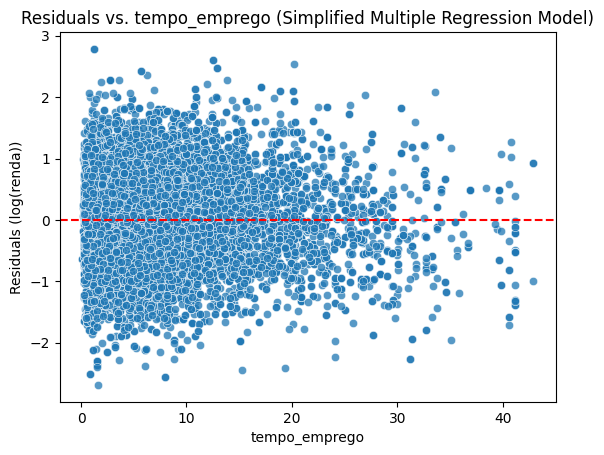

In [14]:
residuals_multiple_simplified = results_multiple_simplified.resid

sns.scatterplot(x=X_multiple_simplified['tempo_emprego'], y=residuals_multiple_simplified, alpha=.75)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('tempo_emprego')
plt.ylabel('Residuals (log(renda))')
plt.title('Residuals vs. tempo_emprego (Simplified Multiple Regression Model)')
plt.show()

A análise dos resíduos mostra um ajuste melhor, comparado com o modelo de regressão linear simples.

Homocedasticidade: Os resíduos parecem estar distribuidos de maneira mais uniforme em torno do zero, sem apresentar um formato de funil ou de cone, de acordo com o crescimento da variável `tempo_emprego`. Isso sugere uma variância constante dos resíduos melhor, devido a transformação logarítimica da variável `renda`, e a inclusão de mais variáveis.

A distribuição dos resíduos não apresenta um padrão, indicando que a relação linear entre `np.log(renda)` e `tempo_emprego` é apropriada.

O aumento do valor de R2 mostra que uma porcentagem maior da variância é explicada pelo modelo, se comparado com o ajuste inicial.

Os testes estatísticos (Omnibus e Jarque-Bera) indicam uma normalidade nos resíduos.

O Condition Number alto ainda indica alguma multicolinearidade entre alguns preditores, mas pela análise gráfica dos resíduos, o modelo parece performar bem em termos de ajuste de dados, e melhorando a regressão depois da transformação logarítimica.